# Time series analysis

In [ ]:
%load_ext autoreload
%autoreload 2


<IPython.core.display.Javascript object>

In [2]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

<IPython.core.display.Javascript object>

A **time series** is a sequence of measurements from a system that varies in time.
One famous example is the "hockey stick graph" that shows global average temperature over time (see <https://en.wikipedia.org/wiki/Hockey_stick_graph>).

The example I work with in this chapter comes from Zachary M. Jones, a researcher in political science who studies the black market for cannabis in the U.S. (<http://zmjones.com/marijuana>).
He collected data from a web site called "Price of Weed" that crowdsources market information by asking participants to report the price, quantity, quality, and location of cannabis transactions (<http://www.priceofweed.com/>).
The goal of his project is to investigate the effect of policy decisions, like legalization, on markets.
I find this project appealing because it is an example that uses data to address important political questions, like drug policy.

I hope you will find this chapter interesting, but I'll take this opportunity to reiterate the importance of maintaining a professional attitude to data analysis.
Whether and which drugs should be illegal are important and difficult public policy questions; our decisions should be informed by accurate data reported honestly.

## Electricity

In [4]:
elec = (
    pd.read_csv("Net_generation_for_all_sectors.csv", skiprows=4)
    .drop(columns=["units", "source key"])
    .set_index("description")
    .replace("--", np.nan)
    .transpose()
    .infer_objects(copy=False)
)
elec.head()

description,Net generation for all sectors,United States,United States : all fuels (utility-scale),United States : nuclear,United States : conventional hydroelectric,United States : other renewables,United States : wind,United States : all utility-scale solar,United States : geothermal,United States : biomass,United States : hydro-electric pumped storage,United States : all solar,United States : small-scale solar photovoltaic
Jan 2001,NaN,NaN,NaN,68707,18852,NaN,389,7,1229,4400,-589,NaN,NaN
Feb 2001,NaN,NaN,NaN,61272,17473,NaN,431,13,1073,3793,-707,NaN,NaN
Mar 2001,NaN,NaN,NaN,62141,20477,NaN,532,31,1190,4042,-773,NaN,NaN
Apr 2001,NaN,NaN,NaN,56003,18013,NaN,685,39,1095,4008,-796,NaN,NaN
May 2001,NaN,NaN,NaN,61512,19176,NaN,635,81,1071,3951,-623,NaN,NaN


<IPython.core.display.Javascript object>

In [121]:
elec = (
    pd.read_csv("Net_generation_for_all_sectors.csv", skiprows=4)
    .drop(columns=["units", "source key"])
    .set_index("description")
    .replace("--", np.nan)
    .transpose()
    .astype(float)
)
elec.head()

description,Net generation for all sectors,United States,United States : all fuels (utility-scale),United States : nuclear,United States : conventional hydroelectric,United States : other renewables,United States : wind,United States : all utility-scale solar,United States : geothermal,United States : biomass,United States : hydro-electric pumped storage,United States : all solar,United States : small-scale solar photovoltaic
Jan 2001,NaN,NaN,NaN,68707.0,18852.0,NaN,389.0,7.0,1229.0,4400.0,-589.0,NaN,NaN
Feb 2001,NaN,NaN,NaN,61272.0,17473.0,NaN,431.0,13.0,1073.0,3793.0,-707.0,NaN,NaN
Mar 2001,NaN,NaN,NaN,62141.0,20477.0,NaN,532.0,31.0,1190.0,4042.0,-773.0,NaN,NaN
Apr 2001,NaN,NaN,NaN,56003.0,18013.0,NaN,685.0,39.0,1095.0,4008.0,-796.0,NaN,NaN
May 2001,NaN,NaN,NaN,61512.0,19176.0,NaN,635.0,81.0,1071.0,3951.0,-623.0,NaN,NaN


<IPython.core.display.Javascript object>

In [122]:
elec.index = pd.to_datetime(elec.index, format="%b %Y")
elec.index = pd.date_range(start="2001-01", periods=len(elec), freq="ME")

<IPython.core.display.Javascript object>

In [124]:
solar_util = elec["United States : all utility-scale solar"]
small_solar = elec["United States : small-scale solar photovoltaic"]

<IPython.core.display.Javascript object>

<Axes: >

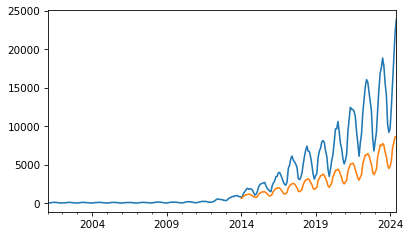

<IPython.core.display.Javascript object>

In [125]:
solar_util.plot()
small_solar.plot()

## Decomposition

<Axes: >

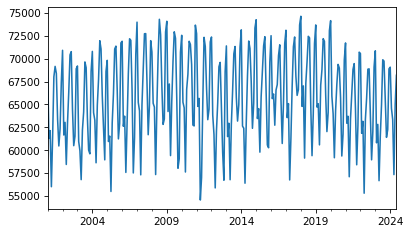

<IPython.core.display.Javascript object>

In [8]:
nuclear = elec["United States : nuclear"].astype(float)
nuclear.plot()

<Axes: >

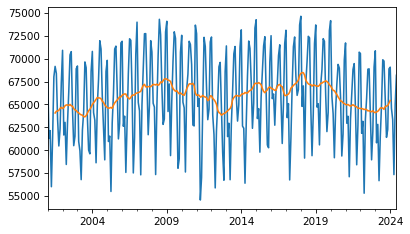

<IPython.core.display.Javascript object>

In [9]:
trend = nuclear.rolling(window=12, center=True).mean()
nuclear.plot()
trend.plot()

<Axes: >

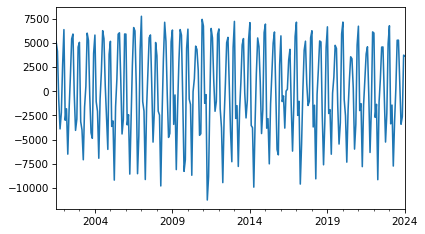

<IPython.core.display.Javascript object>

In [10]:
detrended = (nuclear - trend).dropna()
detrended.plot()

<Axes: >

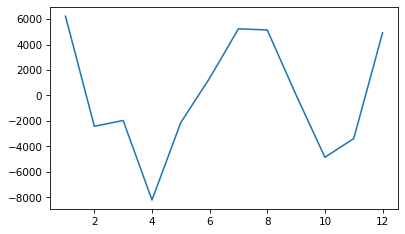

<IPython.core.display.Javascript object>

In [11]:
monthly_averages = detrended.groupby(detrended.index.month).mean()
monthly_averages.plot()

<Axes: >

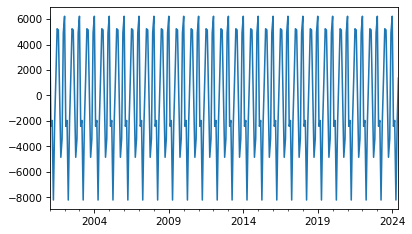

<IPython.core.display.Javascript object>

In [12]:
seasonal = monthly_averages[nuclear.index.month]
seasonal.index = nuclear.index
seasonal.plot()

<Axes: >

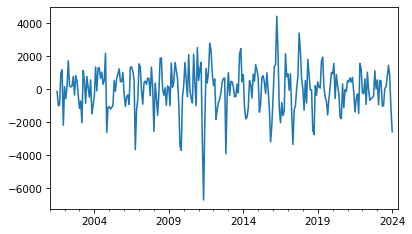

<IPython.core.display.Javascript object>

In [13]:
resid = nuclear - trend - seasonal
resid.plot()

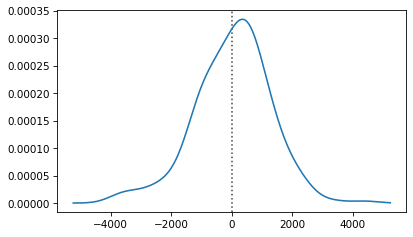

<IPython.core.display.Javascript object>

In [14]:
from thinkstats import plot_kde

plot_kde(resid.dropna())

In [15]:
rsquared = 1 - resid.var() / nuclear.var()
rsquared

0.9248038288734188

<IPython.core.display.Javascript object>

In [16]:
def plot_decomposition(original, decomposition):
    plt.figure(figsize=(6, 5))

    plt.subplot(4, 1, 1)
    plt.plot(original, label="Original", color="C0")
    plt.ylabel("Original")

    plt.subplot(4, 1, 2)
    plt.plot(decomposition.trend, label="Trend", color="C1")
    plt.ylabel("Trend")

    plt.subplot(4, 1, 3)
    plt.plot(decomposition.seasonal, label="Seasonal", color="C2")
    plt.ylabel("Seasonal")

    plt.subplot(4, 1, 4)
    plt.plot(decomposition.resid, label="Residual", color="C3")
    plt.ylabel("Residual")

    plt.tight_layout()

<IPython.core.display.Javascript object>

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(nuclear, model="additive", period=12)

<IPython.core.display.Javascript object>

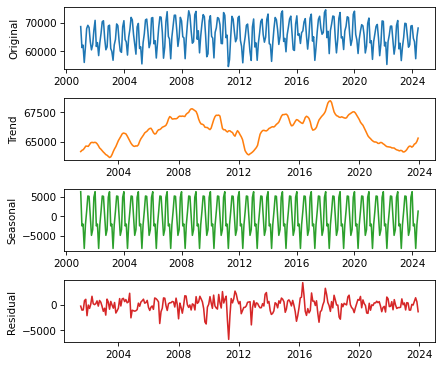

<IPython.core.display.Javascript object>

In [18]:
plot_decomposition(nuclear, decomposition)

## Prediction


In [19]:
t0 = trend.index[0]
years = trend.index.year - t0.year
months = years * 12 + trend.index.month - t0.month

data = pd.DataFrame({"trend": trend, "months": months}).dropna()

import statsmodels.formula.api as smf

results = smf.ols("trend ~ months", data=data).fit()

from thinkstats import display_summary

display_summary(results)

<IPython.core.display.Javascript object>

In [23]:
month_range = np.arange(months.min(), months.max() + 5 * 12)
df = pd.DataFrame({"months": month_range})
pred_trend = results.predict(df)

<IPython.core.display.Javascript object>

In [24]:
pred_trend.index = [t0 + pd.DateOffset(months=months) for months in month_range]

<IPython.core.display.Javascript object>

<Axes: >

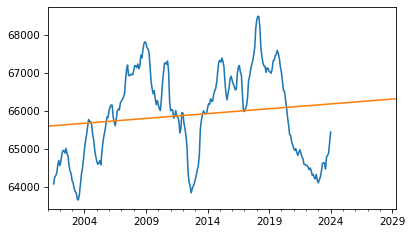

<IPython.core.display.Javascript object>

In [25]:
trend.plot()
pred_trend.plot()

<Axes: >

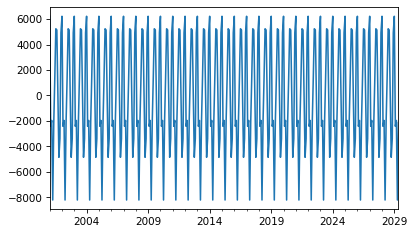

<IPython.core.display.Javascript object>

In [26]:
pred_seasonal = monthly_averages[pred_trend.index.month]
pred_seasonal.index = pred_trend.index
pred_seasonal.plot()

<Axes: >

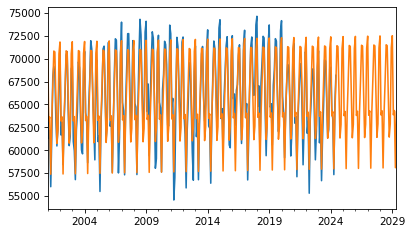

<IPython.core.display.Javascript object>

In [27]:
pred = pred_trend + pred_seasonal

nuclear.plot()
pred.plot()

<Axes: >

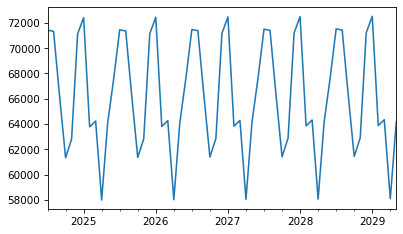

<IPython.core.display.Javascript object>

In [28]:
future = pred[pred.index > trend.index[-1]]
future.plot()

In [29]:
def resample_pred(pred, m, s):
    return pred + np.random.normal(m, s, len(pred))

<IPython.core.display.Javascript object>

In [30]:
m, s = resid.mean(), resid.std()

<IPython.core.display.Javascript object>

In [31]:
pred_seq = [resample_pred(future, m, s) for i in range(201)]

<IPython.core.display.Javascript object>

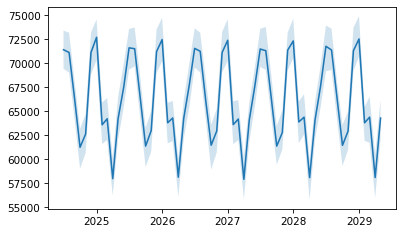

<IPython.core.display.Javascript object>

In [32]:
low, median, high = np.percentile(pred_seq, [5, 50, 95], axis=0)
plt.fill_between(future.index, low, high, alpha=0.2)
plt.plot(future.index, median)


## Multiplicative Model

In [129]:
solar = elec["United States : small-scale solar photovoltaic"].dropna()

<IPython.core.display.Javascript object>

<Axes: >

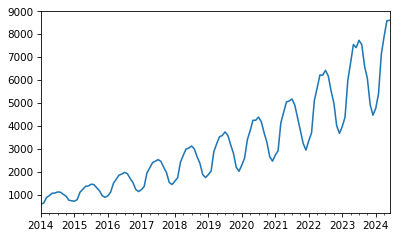

<IPython.core.display.Javascript object>

In [130]:
solar.plot()

In [131]:
decomposition = seasonal_decompose(solar, model="multiplicative", period=12)

<IPython.core.display.Javascript object>

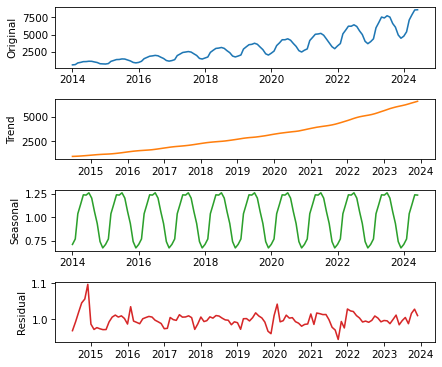

<IPython.core.display.Javascript object>

In [36]:
plot_decomposition(solar, decomposition)

In [37]:
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

<IPython.core.display.Javascript object>

In [38]:
rsquared = 1 - resid.var() / solar.var()
rsquared

0.9999999999031347

<IPython.core.display.Javascript object>

In [39]:
t0 = trend.index[0]
years = trend.index.year - t0.year
months = years * 12 + trend.index.month - t0.month

<IPython.core.display.Javascript object>

In [40]:
data = pd.DataFrame({"trend": trend, "months": months}).dropna()

<IPython.core.display.Javascript object>

In [41]:
results = smf.ols("trend ~ months + I(months**2)", data=data).fit()
display_summary(results)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,981.0448,32.384,30.295,0.000,916.875,1045.215
months,9.3753,1.186,7.904,0.000,7.025,11.726
I(months ** 2),0.3080,0.009,33.350,0.000,0.290,0.326


R-squared:,0.9966


<IPython.core.display.Javascript object>

In [42]:
month_range = np.arange(months.min(), months.max() + 5 * 12)
df = pd.DataFrame({"months": month_range})
pred_trend = results.predict(df)

<IPython.core.display.Javascript object>

In [43]:
pred_trend.index = [t0 + pd.DateOffset(months=months) for months in month_range]

<IPython.core.display.Javascript object>

<Axes: >

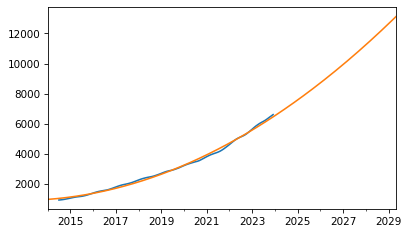

<IPython.core.display.Javascript object>

In [44]:
trend.plot()
pred_trend.plot()

In [45]:
monthly_averages = seasonal.groupby(seasonal.index.month).mean()

<IPython.core.display.Javascript object>

<Axes: >

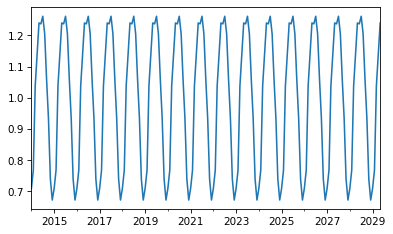

<IPython.core.display.Javascript object>

In [46]:
pred_seasonal = monthly_averages[pred_trend.index.month]
pred_seasonal.index = pred_trend.index
pred_seasonal.plot()

<Axes: >

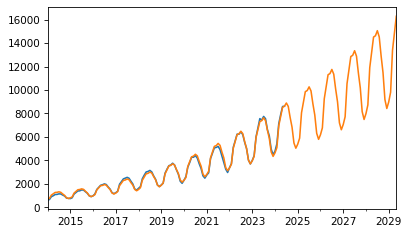

<IPython.core.display.Javascript object>

In [47]:
pred = pred_trend * pred_seasonal

solar.plot()
pred.plot()

<Axes: >

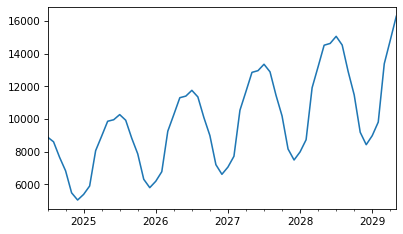

<IPython.core.display.Javascript object>

In [48]:
future = pred[pred.index > trend.index[-1]]
future.plot()

In [49]:
def resample_pred_multiplicative(pred, m, s):
    return pred * np.random.normal(m, s, len(pred))

<IPython.core.display.Javascript object>

In [50]:
m, s = resid.mean(), resid.std()

<IPython.core.display.Javascript object>

In [51]:
pred_seq = [resample_pred_multiplicative(future, m, s) for i in range(201)]

<IPython.core.display.Javascript object>

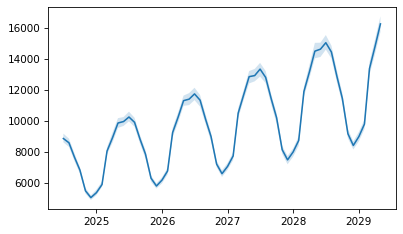

<IPython.core.display.Javascript object>

In [52]:
low, median, high = np.percentile(pred_seq, [5, 50, 95], axis=0)
plt.fill_between(future.index, low, high, alpha=0.2)
plt.plot(future.index, median)

## Autoregression


<Axes: >

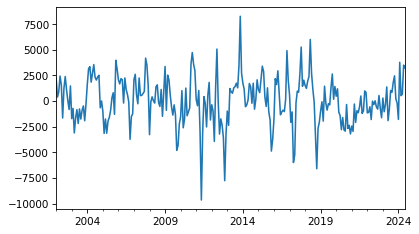

<IPython.core.display.Javascript object>

In [53]:
diff = (nuclear - nuclear.shift(12)).dropna()
diff.plot()

In [54]:
df_ar = pd.DataFrame({"diff": diff})
for lag in [1, 2, 3]:
    df_ar[f"lag{lag}"] = diff.shift(lag)

df_ar = df_ar.dropna()

<IPython.core.display.Javascript object>

In [55]:
df_ar.corr()[["diff"]]

,diff
diff,1.000000
lag1,0.562212
lag2,0.292454
lag3,0.222228


<IPython.core.display.Javascript object>

In [56]:
def make_formula(df):
    y = df.columns[0]
    xs = " + ".join(df.columns[1:])
    return f"{y} ~ {xs}"

<IPython.core.display.Javascript object>

In [57]:
formula = make_formula(df_ar)
results_ar = smf.ols(formula=formula, data=df_ar).fit()
display_summary(results_ar)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,24.2674,114.674,0.212,0.833,-201.528,250.063
lag1,0.5847,0.061,9.528,0.000,0.464,0.706
lag2,-0.0908,0.071,-1.277,0.203,-0.231,0.049
lag3,0.1026,0.062,1.666,0.097,-0.019,0.224


R-squared:,0.3239


<IPython.core.display.Javascript object>

<Axes: >

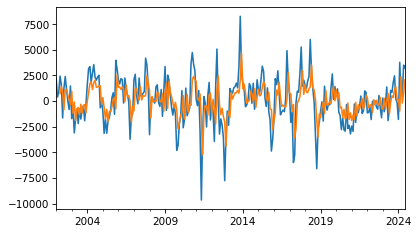

<IPython.core.display.Javascript object>

In [58]:
pred_ar = results_ar.predict(df_ar)
diff.plot()
pred_ar.plot()

In [59]:
resid_ar = results_ar.resid
R2 = 1 - resid_ar.var() / diff.var()
R2

0.3190252265690783

<IPython.core.display.Javascript object>

## Moving Average

In [60]:
df_ma = pd.DataFrame({"resid": resid_ar})

for lag in [1, 6]:
    df_ma[f"lag{lag}"] = resid_ar.shift(lag)

df_ma = df_ma.dropna()

<IPython.core.display.Javascript object>

In [61]:
formula = make_formula(df_ma)
formula

'resid ~ lag1 + lag6'

<IPython.core.display.Javascript object>

In [62]:
results_ma = smf.ols(formula=formula, data=df_ma).fit()
display_summary(results_ma)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-14.0016,114.697,-0.122,0.903,-239.863,211.860
lag1,0.0014,0.062,0.023,0.982,-0.120,0.123
lag6,-0.1592,0.063,-2.547,0.011,-0.282,-0.036


R-squared:,0.0247


<IPython.core.display.Javascript object>

In [63]:
pred_ma = results_ma.predict(df_ma)

<IPython.core.display.Javascript object>

In [64]:
pred_diff = pred_ar + pred_ma

<IPython.core.display.Javascript object>

In [65]:
resid = (diff - pred_diff).dropna()
R2 = 1 - resid.var() / diff.var()
R2

0.3315101001391231

<IPython.core.display.Javascript object>

In [66]:
pred_diff = pd.Series(pred_diff, index=nuclear.index)
offset = pred_diff.isna().sum()
offset

21

<IPython.core.display.Javascript object>

In [67]:
pred_series = pd.Series(index=nuclear.index, dtype=float)
pred_series.iloc[:offset] = nuclear.iloc[:offset]

<IPython.core.display.Javascript object>

In [68]:
for i in range(offset, len(pred_series)):
    pred_series.iloc[i] = pred_series.iloc[i - 12] + pred_diff.iloc[i]

pred_series[:offset] = np.nan

<IPython.core.display.Javascript object>

<Axes: >

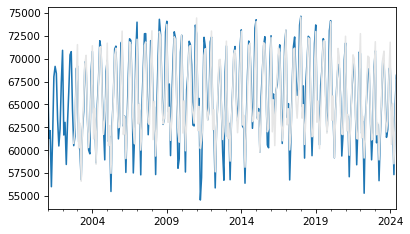

<IPython.core.display.Javascript object>

In [69]:
nuclear.plot()
pred_series.plot(color="0.9")

In [70]:
resid = (nuclear - pred_series).dropna()
R2 = 1 - resid.var() / nuclear.var()
R2

0.8586566911201015

<IPython.core.display.Javascript object>

And it's a similar process to generate forecasts...

## ARIMA

In [71]:
filled = nuclear.resample("ME").ffill()
np.allclose(filled, nuclear)

True

<IPython.core.display.Javascript object>

In [72]:
import statsmodels.tsa.api as tsa

model = tsa.ARIMA(filled, order=(3, 0, [1, 6]), seasonal_order=(0, 1, 0, 12))
results_arima = model.fit()
display_summary(results_arima)

,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.0458,0.379,0.121,0.904,-0.697,0.788
ar.L2,-0.0035,0.116,-0.030,0.976,-0.230,0.223
ar.L3,0.0375,0.049,0.769,0.442,-0.058,0.133
ma.L1,0.2154,0.382,0.564,0.573,-0.533,0.964
ma.L6,-0.0672,0.019,-3.500,0.000,-0.105,-0.030
sigma2,3.473e+06,1.9e-07,1.83e+13,0.000,3.47e+06,3.47e+06


<IPython.core.display.Javascript object>

In [73]:
fittedvalues = results_arima.fittedvalues[offset:]

<IPython.core.display.Javascript object>

<Axes: >

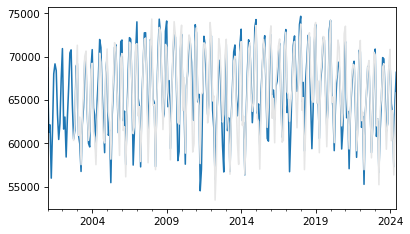

<IPython.core.display.Javascript object>

In [74]:
filled.plot()
fittedvalues.plot(color="0.9")

In [75]:
resid = filled - fittedvalues
R2 = 1 - resid.var() / filled.var()
R2

0.8262717330784233

<IPython.core.display.Javascript object>

In [76]:
forecast = results_arima.get_forecast(steps=60)

<IPython.core.display.Javascript object>

In [77]:
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_ci.columns = ["lower", "upper"]

<IPython.core.display.Javascript object>

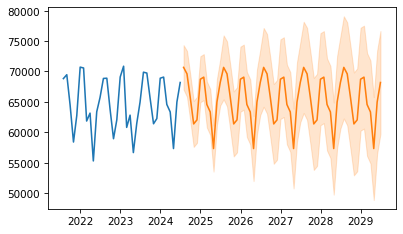

<IPython.core.display.Javascript object>

In [78]:
recent = filled.iloc[-36:]
plt.plot(recent.index, recent)
plt.fill_between(
    forecast_ci.index, forecast_ci.lower, forecast_ci.upper, color="C1", alpha=0.2
)
plt.plot(forecast_mean.index, forecast_mean)

## Exogenous

In [79]:
temps = pd.read_csv("monthly-average-surface-temperatures-by-year.csv")
temps.head()

,Entity,Code,Year,2024,2023,2022,2021,2020,2019,2018,...,1959,1958,1956,1954,1952,1957,1955,1953,1951,1950
0,Afghanistan,AFG,1,3.300064,-4.335608,-0.322859,-1.001608,-2.560545,0.585145,1.042471,...,-2.333814,0.576404,-3.351925,-2.276692,-2.812619,-4.239172,-2.191683,-2.915993,-3.126317,-2.655707
1,Afghanistan,AFG,2,1.024550,4.187041,2.165870,5.688000,2.880046,0.068664,3.622793,...,-1.545529,0.264962,0.455350,-0.304205,0.798226,-2.747945,1.999074,1.983414,-2.642800,-3.996040
2,Afghanistan,AFG,3,5.843506,10.105444,10.483686,9.777976,6.916731,5.758049,10.794412,...,5.942937,7.716459,5.090270,4.357703,4.796146,4.434027,7.066073,4.590406,3.054388,3.491112
3,Afghanistan,AFG,4,11.627398,14.277164,17.227650,15.168276,12.686832,13.838840,14.321226,...,13.752827,14.712909,11.982360,12.155265,13.119270,8.263829,10.418768,11.087193,9.682878,8.332797
4,Afghanistan,AFG,5,18.957850,19.078170,19.962734,19.885902,18.884047,18.461287,18.100782,...,17.388723,16.352045,20.125462,18.432117,17.614851,15.505956,15.599709,17.865084,17.095737,17.329062


<IPython.core.display.Javascript object>

In [80]:
temp_us = temps.query("Code == 'USA'")
columns = [str(year) for year in range(2001, 2025)]
temp_series = temp_us.loc[:, columns].transpose().stack()
temp_series.index = pd.date_range(start="2001-01", periods=len(temp_series), freq="ME")

<IPython.core.display.Javascript object>

<Axes: >

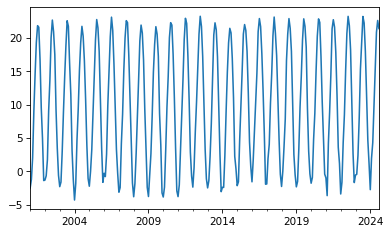

<IPython.core.display.Javascript object>

In [81]:
temp_series.plot()

<Axes: >

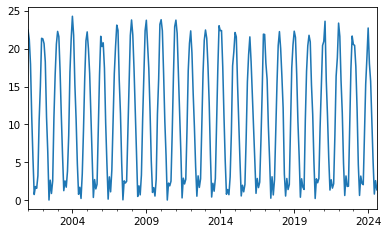

<IPython.core.display.Javascript object>

In [82]:
temp_deviation = (temp_series - 20).abs()
temp_deviation.plot()

In [83]:
data = pd.DataFrame({"nuclear": filled, "temp": temp_deviation}).dropna()

<IPython.core.display.Javascript object>

In [84]:
results = smf.ols("nuclear ~ temp", data=data).fit()
display_summary(results)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.617e+04,479.821,137.906,0.000,6.52e+04,6.71e+04
temp,-31.6990,35.487,-0.893,0.372,-101.555,38.157


R-squared:,0.002842


<IPython.core.display.Javascript object>

In [85]:
model = tsa.ARIMA(
    filled, order=(3, 0, [1, 6]), seasonal_order=(0, 1, 0, 12), exog=data["temp"]
)
results_arima = model.fit()
display_summary(results_arima)

,coef,std err,z,P>|z|,[0.025,0.975]
temp,-156.3105,88.099,-1.774,0.076,-328.982,16.361
ar.L1,-0.0074,0.380,-0.019,0.985,-0.752,0.737
ar.L2,-0.0014,0.114,-0.012,0.990,-0.225,0.223
ar.L3,0.0347,0.052,0.670,0.503,-0.067,0.136
ma.L1,0.2518,0.382,0.660,0.510,-0.496,1.000
ma.L6,-0.0609,0.019,-3.210,0.001,-0.098,-0.024
sigma2,3.483e+06,0.005,6.67e+08,0.000,3.48e+06,3.48e+06


<IPython.core.display.Javascript object>

<Axes: >

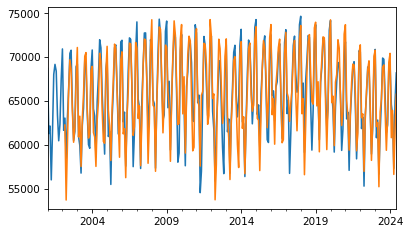

<IPython.core.display.Javascript object>

In [86]:
fittedvalues = results_arima.fittedvalues[14:]
filled.plot()
fittedvalues.plot()

In [87]:
resid = filled - fittedvalues
R2 = 1 - resid.var() / filled.var()
R2

0.8222537833569468

<IPython.core.display.Javascript object>

## The Dow Jones

The [MeasuringWorth Foundation](https://www.measuringworth.com/datasets/DJA) has compiled the value of the Dow Jones Industrial Average at the end of each day from February 16, 1885 to the present, with adjustments at several points to make the values comparable.
The series I collected starts on February 16, 1885 and ends on August 30, 2024.
The following cells download and read the data.

In [88]:
# "Citation: Samuel H. Williamson, 'Daily Closing Value of the Dow Jones Average, 1885 to Present,'
# MeasuringWorth, 2022. "

# Downloaded from https://www.measuringworth.com/datasets/DJA, September 3, 2024

<IPython.core.display.Javascript object>

In [89]:
DATA_PATH = "https://github.com/AllenDowney/ThinkStats/raw/v3/data/"
filename = "DJA.csv"
download(DATA_PATH + filename)

<IPython.core.display.Javascript object>

In [90]:
def fill_series(series, freq="D"):
    index = series.index
    full_date_range = pd.date_range(start=index.min(), end=index.max(), freq=freq)
    return series.reindex(full_date_range).ffill()

<IPython.core.display.Javascript object>

In [91]:
djia = pd.read_csv(filename, skiprows=4, parse_dates=[0], index_col=0)
djia.head()

,DJIA
Date,
1885-02-16,30.9226
1885-02-17,31.3365
1885-02-18,31.4744
1885-02-19,31.6765
1885-02-20,31.4252


<IPython.core.display.Javascript object>

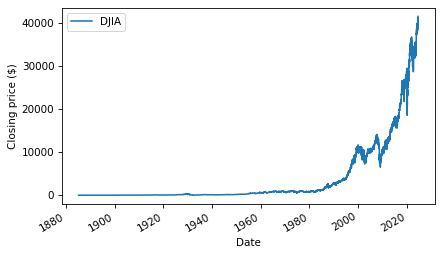

<IPython.core.display.Javascript object>

In [92]:
djia["DJIA"].plot()

decorate(ylabel="Closing price ($)")

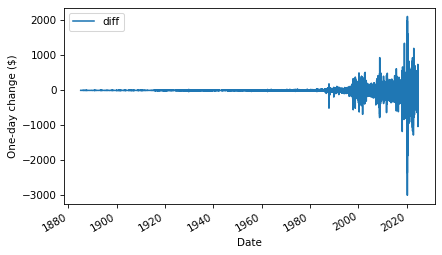

<IPython.core.display.Javascript object>

In [93]:
djia["diff"] = djia["DJIA"].diff()
djia["diff"].plot()

decorate(ylabel="One-day change ($)")

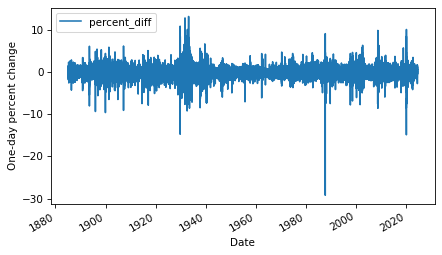

<IPython.core.display.Javascript object>

In [94]:
djia["percent_diff"] = djia["diff"] / djia["DJIA"] * 100
djia["percent_diff"].plot()

decorate(ylabel="One-day percent change")

<Axes: xlabel='percent_diff'>

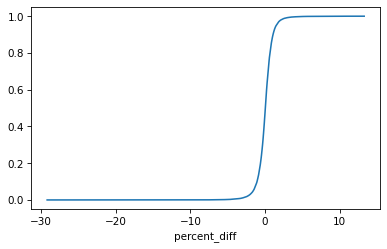

<IPython.core.display.Javascript object>

In [95]:
from empiricaldist import Cdf

cdf_percent_diff = Cdf.from_seq(djia["percent_diff"])
cdf_percent_diff.plot()

In [96]:
up_day = djia.query("percent_diff > 0")
down_day = djia.query("percent_diff < 0")

<IPython.core.display.Javascript object>

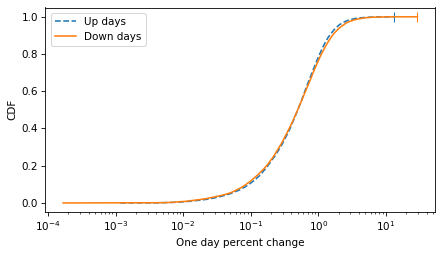

<IPython.core.display.Javascript object>

In [97]:
cdf_up = Cdf.from_seq(up_day["percent_diff"])
cdf_up.plot(label="Up days", ls="--")
plt.plot(cdf_up.qs.max(), 1, "|", color="C0", ms=10)

cdf_down = Cdf.from_seq(-down_day["percent_diff"])
cdf_down.plot(label="Down days")
plt.plot(cdf_down.qs.max(), 1, "|", color="C1", ms=10)

decorate(xlabel="One day percent change", xscale="log", ylabel="CDF")

In [98]:
recent = djia.query('index > "1936-01-01"')

<IPython.core.display.Javascript object>

<Axes: xlabel='Date'>

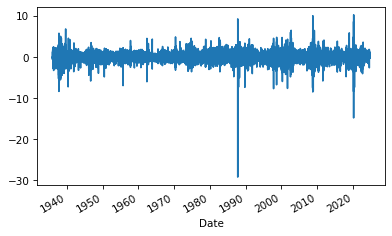

<IPython.core.display.Javascript object>

In [99]:
recent["percent_diff"].plot()

In [100]:
annual = djia.groupby(djia.index.year).last().drop(2024)
annual["diff"] = annual["DJIA"].diff()
annual["percent_diff"] = annual["diff"] / annual["DJIA"].shift(1) * 100
annual

,DJIA,diff,percent_diff
Date,,,
1885,39.4859,NaN,NaN
1886,41.2391,1.7532,4.440066
1887,37.7693,-3.4698,-8.413860
1888,39.5866,1.8173,4.811580
1889,42.0394,2.4528,6.196036
...,...,...,...
2019,28538.4400,5210.9800,22.338394
2020,30606.4800,2068.0400,7.246507
2021,36338.3000,5731.8200,18.727472


<IPython.core.display.Javascript object>

<Axes: xlabel='Date'>

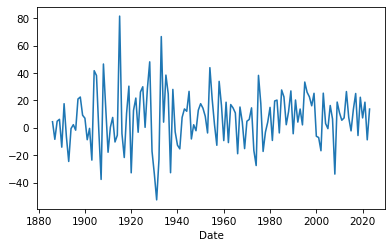

<IPython.core.display.Javascript object>

In [101]:
annual["percent_diff"].plot()

In [102]:
annual["year"] = annual.index
interval = annual.loc[1972:]

<IPython.core.display.Javascript object>

In [103]:
import statsmodels.formula.api as smf

results = smf.ols("percent_diff ~ year", data=interval).fit()
display_summary(results)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-97.0885,290.012,-0.335,0.739,-679.595,485.418
year,0.0529,0.145,0.365,0.717,-0.239,0.345


R-squared:,0.002652


<IPython.core.display.Javascript object>

In [104]:
from statsmodels.tsa.arima.model import ARIMA

# Assuming 'annual' dataframe has 'percent_diff' column for percentage changes
# Step 1: Define the ARIMA model on the percent differences
model = ARIMA(annual['percent_diff'], order=(1, 1, 1))

# Step 2: Fit the model
model_fit = model.fit()

# Step 3: Display the summary
print(model_fit.summary())

# Step 4: Forecast future percent differences
forecast_steps = 10  # Forecast the next 10 periods
forecast = model_fit.forecast(steps=forecast_steps)
print(forecast)


                               SARIMAX Results                                
Dep. Variable:           percent_diff   No. Observations:                  139
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -616.672
Date:                Wed, 18 Sep 2024   AIC                           1239.344
Time:                        11:18:40   BIC                           1248.125
Sample:                             0   HQIC                          1242.912
                                - 139                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0386      0.075     -0.512      0.609      -0.186       0.109
ma.L1         -0.9996      1.401     -0.714      0.475      -3.745       1.746
sigma2       409.2568    574.580      0.712      0.4

/home/downey/miniconda3/envs/ThinkStats/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/downey/miniconda3/envs/ThinkStats/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/downey/miniconda3/envs/ThinkStats/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/downey/miniconda3/envs/ThinkStats/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/downey/miniconda3/envs/ThinkStats/lib/

<IPython.core.display.Javascript object>

Exercise: Check if volatility has increased by running a regression of absolute value of percent change over time

Filling missing dates

In [105]:
fill_series(djia["DJIA"])

1885-02-16       30.9226
1885-02-17       31.3365
1885-02-18       31.4744
1885-02-19       31.6765
1885-02-20       31.4252
                 ...    
2024-08-26    41240.5200
2024-08-27    41250.5000
2024-08-28    41091.4200
2024-08-29    41335.0500
2024-08-30    41563.0800
Freq: D, Name: DJIA, Length: 50965, dtype: float64

<IPython.core.display.Javascript object>

## Glossary

-   **time series**: A dataset where each value is associated with a timestamp, often a series of measurements and the times they were collected.

-   **window**: A sequence of consecutive values in a time series, often used to compute a moving average.

-   **moving average**: One of several statistics intended to estimate the underlying trend in a time series by computing averages (of some kind) for a series of overlapping windows.

-   **rolling mean**: A moving average based on the mean value in each window.

-   **exponentially-weighted moving average (EWMA)**: A moving average based on a weighted mean that gives the highest weight to the most recent values, and exponentially decreasing weights to earlier values.

-   **span**: A parameter of EWMA that determines how quickly the weights decrease.

-   **serial correlation**: Correlation between a time series and a shifted or lagged version of itself.

-   **lag**: The size of the shift in a serial correlation or autocorrelation.

-   **autocorrelation**: A more general term for a serial correlation with any amount of lag.

-   **autocorrelation function**: A function that maps from lag to serial correlation.

-   **stationary**: A model is stationary if the parameters and the distribution of residuals does not change over time.

## Exercises

<Axes: >

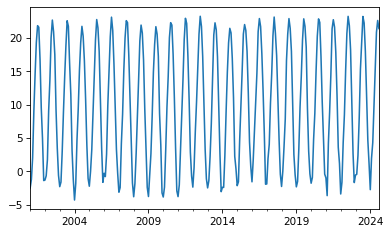

<IPython.core.display.Javascript object>

In [171]:
temp_series.plot()

In [177]:
decomposition = seasonal_decompose(temp_series, model="additive", period=12)

<IPython.core.display.Javascript object>

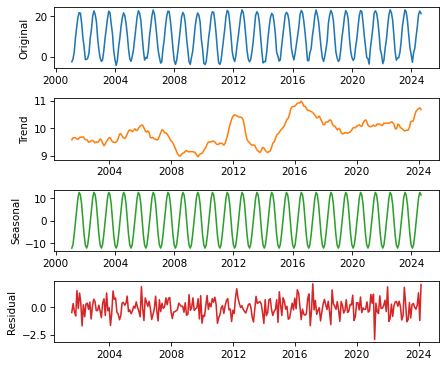

<IPython.core.display.Javascript object>

In [178]:
plot_decomposition(temp_series, decomposition)

In [ ]:
trend = decomposition.trend

In [185]:
t0 = trend.index[0]
years = trend.index.year - t0.year
months = years * 12 + trend.index.month - t0.month

<IPython.core.display.Javascript object>

In [186]:
data = pd.DataFrame({"trend": trend, "months": months}).dropna()

<IPython.core.display.Javascript object>

In [187]:
results = smf.ols("trend ~ months + I(months**2)", data=data).fit()
display_summary(results)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,9.5552,0.077,124.614,0.000,9.404,9.706
months,0.0002,0.001,0.162,0.871,-0.002,0.003
I(months ** 2),1.04e-05,4.28e-06,2.430,0.016,1.97e-06,1.88e-05


R-squared:,0.3003


<IPython.core.display.Javascript object>

In [188]:
month_range = np.arange(months.min(), months.max() + 5 * 12)
df = pd.DataFrame({"months": month_range})
pred_trend = results.predict(df)

<IPython.core.display.Javascript object>

In [189]:
pred_trend.index = [t0 + pd.DateOffset(months=months) for months in month_range]

<IPython.core.display.Javascript object>

<Axes: >

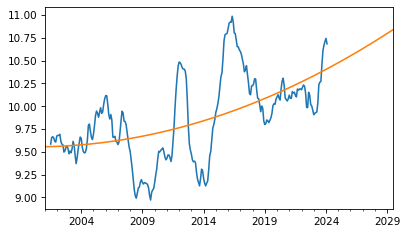

<IPython.core.display.Javascript object>

In [190]:
trend.plot()
pred_trend.plot()

In [196]:
seasonal = decomposition.seasonal
monthly_averages = seasonal.groupby(seasonal.index.month).mean()

<IPython.core.display.Javascript object>

In [197]:
pred_seasonal = monthly_averages[pred_trend.index.month]
pred_seasonal.index = pred_trend.index

<IPython.core.display.Javascript object>

<Axes: >

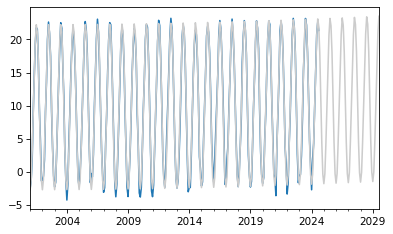

<IPython.core.display.Javascript object>

In [200]:
pred = pred_trend + pred_seasonal

temp_series.plot()
pred.plot(color="0.8")

## Exercise

Utility-scale solar power, multiplicative model

In [132]:
solar = elec["United States : all utility-scale solar"].dropna()

<IPython.core.display.Javascript object>

In [148]:
solar = solar[solar.index.year >= 2014]

<IPython.core.display.Javascript object>

<Axes: >

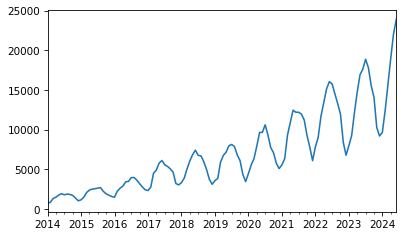

<IPython.core.display.Javascript object>

In [149]:
solar.plot()

In [150]:
decomposition = seasonal_decompose(solar, model="multiplicative", period=12)

<IPython.core.display.Javascript object>

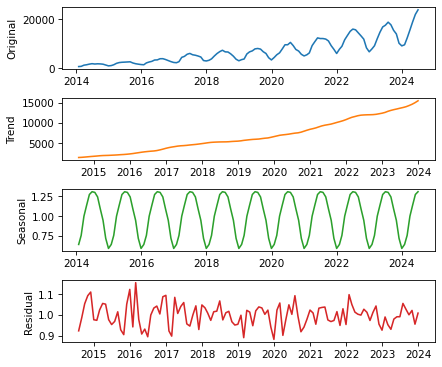

<IPython.core.display.Javascript object>

In [151]:
plot_decomposition(solar, decomposition)

In [152]:
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

<IPython.core.display.Javascript object>

In [153]:
rsquared = 1 - resid.var() / solar.var()
rsquared

0.9999999998865255

<IPython.core.display.Javascript object>

In [154]:
t0 = trend.index[0]
years = trend.index.year - t0.year
months = years * 12 + trend.index.month - t0.month

<IPython.core.display.Javascript object>

In [155]:
data = pd.DataFrame({"trend": trend, "months": months}).dropna()

<IPython.core.display.Javascript object>

In [156]:
results = smf.ols("trend ~ months + I(months**2)", data=data).fit()
display_summary(results)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1543.9346,111.941,13.792,0.000,1322.116,1765.753
months,27.8715,4.100,6.798,0.000,19.747,35.996
I(months ** 2),0.7041,0.032,22.052,0.000,0.641,0.767


R-squared:,0.993


<IPython.core.display.Javascript object>

In [157]:
month_range = np.arange(months.min(), months.max() + 5 * 12)
df = pd.DataFrame({"months": month_range})
pred_trend = results.predict(df)

<IPython.core.display.Javascript object>

In [158]:
pred_trend.index = [t0 + pd.DateOffset(months=months) for months in month_range]

<IPython.core.display.Javascript object>

<Axes: >

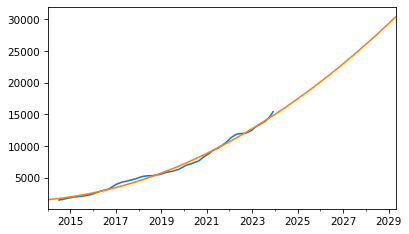

<IPython.core.display.Javascript object>

In [159]:
trend.plot()
pred_trend.plot()

In [160]:
monthly_averages = seasonal.groupby(seasonal.index.month).mean()

<IPython.core.display.Javascript object>

<Axes: >

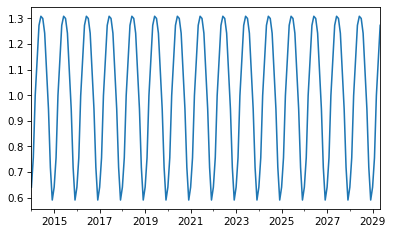

<IPython.core.display.Javascript object>

In [161]:
pred_seasonal = monthly_averages[pred_trend.index.month]
pred_seasonal.index = pred_trend.index
pred_seasonal.plot()

<Axes: >

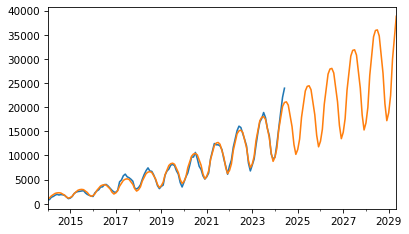

<IPython.core.display.Javascript object>

In [162]:
pred = pred_trend * pred_seasonal

solar.plot()
pred.plot()